In [52]:
# ============================================================
# EDA & Baseline Model – Outpatient Dataset
# Clinical Analytics Dashboard
# Author: Yoander Madera
# ============================================================

# -----------------------------
# 1. Import libraries
# -----------------------------
# Pandas and NumPy for data manipulation
import pandas as pd
import numpy as np

# Matplotlib and Seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure pandas display options for easier inspection
pd.set_option('display.max_columns', None)

# -----------------------------
# 2. Load dataset from GitHub
# -----------------------------
# The CSV file is stored in the public GitHub repository:
# https://github.com/Mrwood30/clinical-analytics-dashboard
# We use the RAW link so that pandas can read it directly.

url = "https://raw.githubusercontent.com/Mrwood30/clinical-analytics-dashboard/main/outpatient_raw.csv"

# Each row represents a single outpatient consultation.
df = pd.read_csv(url)

# Preview the first rows to confirm that the file loaded correctly.
df.head()


,visit_id,consultation_date,consultation_time,specialty,patient_age,gender,waiting_time_min,consultation_time_min,diagnosis_code,diagnosis_description,reason_for_visit,no_show,urgency_level,physician_id,previous_no_show_count,days_between_booking_and_visit
0,1,2024-11-23,08:00,Psychiatry,35,Male,29,27,K21.9,Gastro-esophageal reflux,New complaint,No,Low,DOC007,4,14
1,2,2024-09-15,16:00,Ophthalmology,25,Female,28,25,J06.9,Acute upper respiratory infection,Medication refill,No,Low,DOC025,3,21
2,3,2024-02-22,08:45,Orthopedics,45,Female,3,11,N39.0,Urinary tract infection,Imaging results review,No,Low,DOC018,0,18
3,4,2024-11-17,16:30,Neurology,24,Male,35,19,R07.4,Chest pain,New complaint,No,Low,DOC015,1,40
4,5,2024-07-05,09:30,Dermatology,26,Female,18,9,I10,Essential (primary) hypertension,Chronic disease control,No,Low,DOC015,1,24


In [53]:
# ============================================================
# 3. Basic dataset exploration
# ============================================================

# Check the structure of the dataframe:
# column names, data types, and non-null counts.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   visit_id                        3000 non-null   int64 
 1   consultation_date               3000 non-null   object
 2   consultation_time               3000 non-null   object
 3   specialty                       3000 non-null   object
 4   patient_age                     3000 non-null   int64 
 5   gender                          3000 non-null   object
 6   waiting_time_min                3000 non-null   int64 
 7   consultation_time_min           3000 non-null   int64 
 8   diagnosis_code                  3000 non-null   object
 9   diagnosis_description           3000 non-null   object
 10  reason_for_visit                3000 non-null   object
 11  no_show                         3000 non-null   object
 12  urgency_level                   3000 non-null   

In [54]:
# Number of rows and columns (patients/visits x variables).
df.shape


(3000, 16)

In [55]:
# Descriptive statistics for numeric and categorical columns.
# This provides an initial sense of ranges, distributions,
# and potential anomalies.
df.describe(include='all')


,visit_id,consultation_date,consultation_time,specialty,patient_age,gender,waiting_time_min,consultation_time_min,diagnosis_code,diagnosis_description,reason_for_visit,no_show,urgency_level,physician_id,previous_no_show_count,days_between_booking_and_visit
count,3000.000000,3000,3000,3000,3000.000000,3000,3000.000000,3000.000000,3000,3000,3000,3000,3000,3000,3000.000000,3000.000000
unique,NaN,365,56,13,NaN,2,NaN,NaN,10,10,10,2,3,30,NaN,NaN
top,NaN,2024-12-22,11:00,General Surgery,NaN,Female,NaN,NaN,M54.5,Low back pain,Chronic disease control,No,Low,DOC021,NaN,NaN
freq,NaN,18,68,252,NaN,1558,NaN,NaN,323,323,321,2488,1479,120,NaN,NaN
mean,1500.500000,NaN,NaN,NaN,44.419667,NaN,25.294667,17.602333,NaN,NaN,NaN,NaN,NaN,NaN,1.958667,30.251333
std,866.169729,NaN,NaN,NaN,26.440901,NaN,14.454278,5.755105,NaN,NaN,NaN,NaN,NaN,NaN,1.409357,17.529592
min,1.000000,NaN,NaN,NaN,0.000000,NaN,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,750.750000,NaN,NaN,NaN,21.000000,NaN,15.000000,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,15.000000
50%,1500.500000,NaN,NaN,NaN,44.000000,NaN,25.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,30.000000
75%,2250.250000,NaN,NaN,NaN,67.000000,NaN,35.000000,21.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,46.000000


In [56]:
# Check for missing values in each column.
# In a clinical context, missing data handling is critical.
df.isnull().sum()


,0
visit_id,0
consultation_date,0
consultation_time,0
specialty,0
patient_age,0
gender,0
waiting_time_min,0
consultation_time_min,0
diagnosis_code,0
diagnosis_description,0


In [57]:
# Quick look at the unique values for some key categorical variables.
print("Unique specialties:", df["specialty"].unique())
print("\nUnique urgency levels:", df["urgency_level"].unique())
print("\nUnique no_show values:", df["no_show"].unique())


Unique specialties: ['Psychiatry' 'Ophthalmology' 'Orthopedics' 'Neurology' 'Dermatology'
 'Emergency Medicine' 'Internal Medicine' 'Urology' 'Endocrinology'
 'General Surgery' 'General Medicine' 'Pediatrics' 'Cardiology']

Unique urgency levels: ['Low' 'High' 'Medium']

Unique no_show values: ['No' 'Yes']


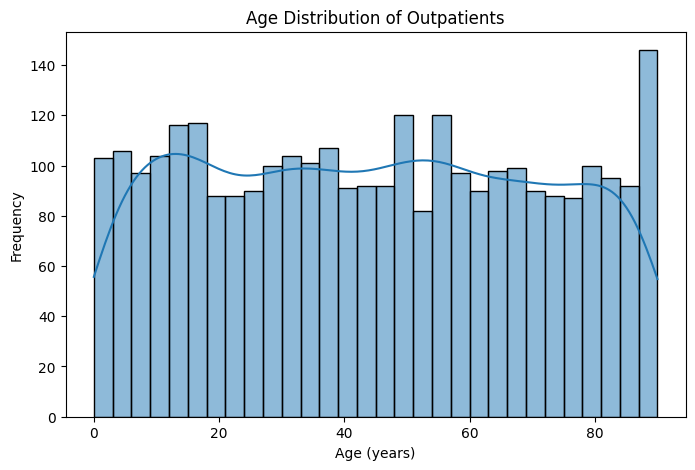

In [58]:
# ============================================================
# 4. Univariate distributions
# ============================================================

# 4.1 Age distribution
# This helps understand the population profile served by the clinic.
plt.figure(figsize=(8,5))
sns.histplot(df["patient_age"], kde=True, bins=30)
plt.title("Age Distribution of Outpatients")
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.show()


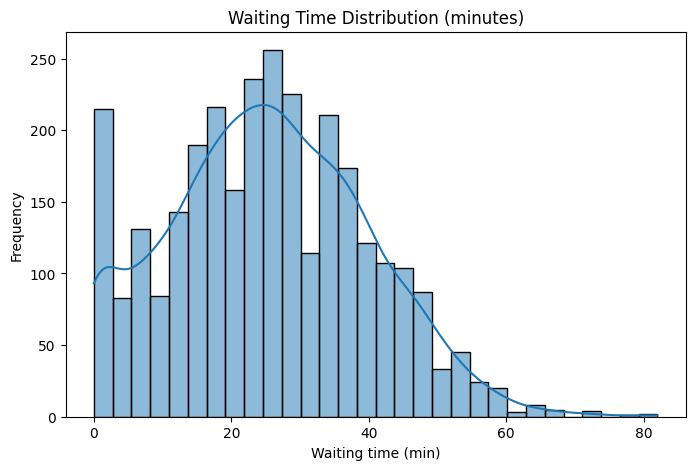

In [59]:
# 4.2 Waiting time distribution
# Long waiting times may negatively affect patient satisfaction
# and could be associated with no-show or cancellation behavior.
plt.figure(figsize=(8,5))
sns.histplot(df["waiting_time_min"], kde=True, bins=30)
plt.title("Waiting Time Distribution (minutes)")
plt.xlabel("Waiting time (min)")
plt.ylabel("Frequency")
plt.show()

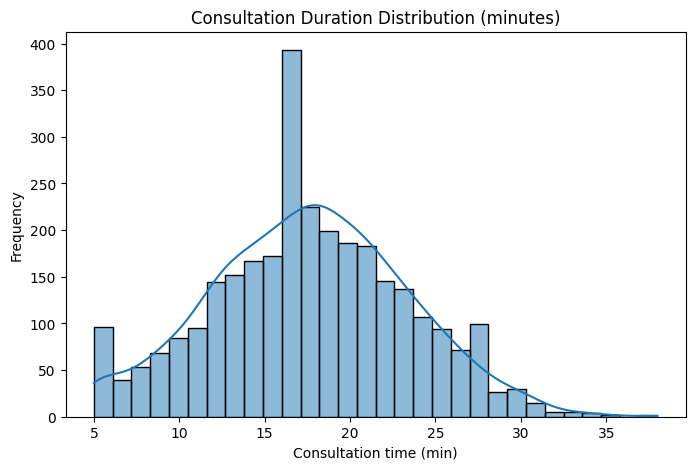

In [60]:
# 4.3 Consultation duration distribution
plt.figure(figsize=(8,5))
sns.histplot(df["consultation_time_min"], kde=True, bins=30)
plt.title("Consultation Duration Distribution (minutes)")
plt.xlabel("Consultation time (min)")
plt.ylabel("Frequency")
plt.show()


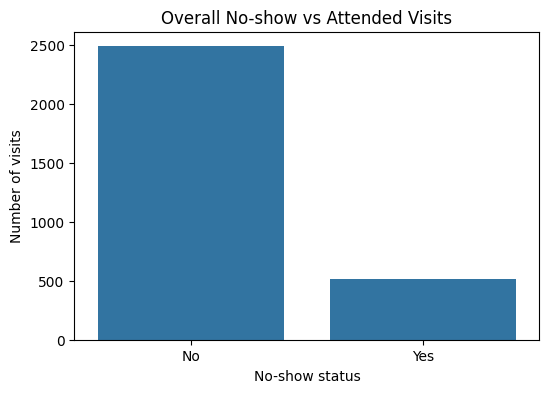

no_show
No     82.933333
Yes    17.066667
Name: proportion, dtype: float64


In [61]:
# ============================================================
# 5. No-show analysis (target variable)
# ============================================================

# 5.1 Overall no-show vs show distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="no_show")
plt.title("Overall No-show vs Attended Visits")
plt.xlabel("No-show status")
plt.ylabel("Number of visits")
plt.show()

# Calculate the relative frequency (percentage) of each class.
no_show_rates = df["no_show"].value_counts(normalize=True) * 100
print(no_show_rates)

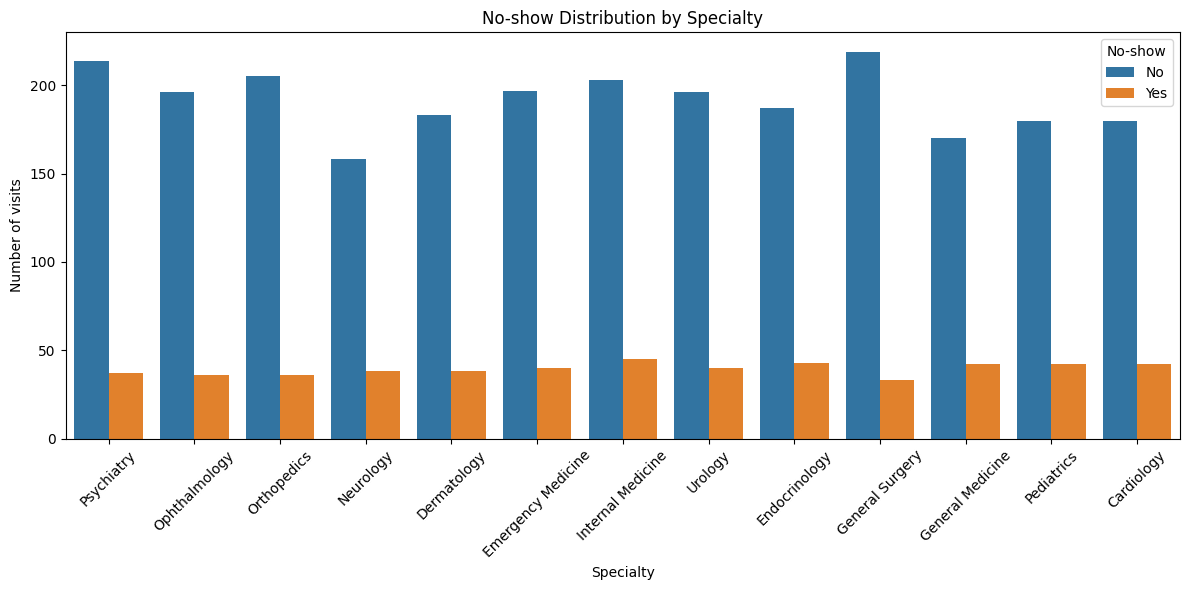

In [62]:
# 5.2 No-show by specialty
# This visualization helps identify specialties with higher
# risk of missed appointments, which is relevant for reminder
# strategies and capacity planning.
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="specialty", hue="no_show")
plt.title("No-show Distribution by Specialty")
plt.xlabel("Specialty")
plt.ylabel("Number of visits")
plt.xticks(rotation=45)
plt.legend(title="No-show")
plt.tight_layout()
plt.show()

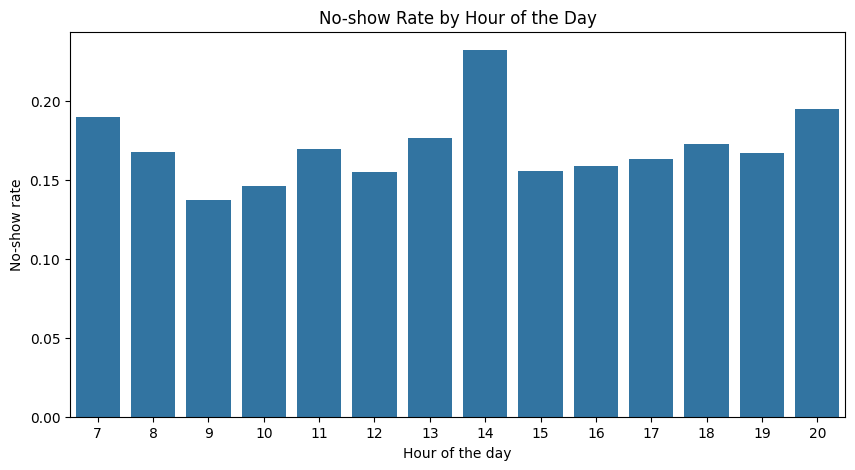

In [63]:
# ============================================================
# 6. Time-based features and analysis
# ============================================================

# 6.1 Extract consultation hour from the time string.
# This allows us to analyze no-shows and volume by hour of day.
df["hour"] = pd.to_datetime(df["consultation_time"], format="%H:%M").dt.hour

# 6.2 No-show rate by hour of the day
# We compute the proportion of 'Yes' for each hour.
no_show_by_hour = df.groupby("hour")["no_show"].apply(lambda x: (x == "Yes").mean()).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=no_show_by_hour, x="hour", y="no_show")
plt.title("No-show Rate by Hour of the Day")
plt.xlabel("Hour of the day")
plt.ylabel("No-show rate")
plt.show()

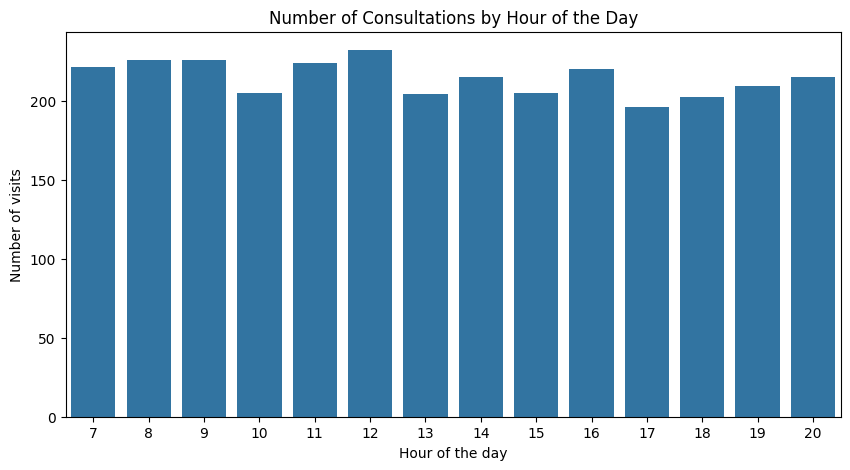

In [64]:
# 6.3 Volume of consultations by hour
# This shows the operational load throughout the day.
visits_by_hour = df["hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.barplot(x=visits_by_hour.index, y=visits_by_hour.values)
plt.title("Number of Consultations by Hour of the Day")
plt.xlabel("Hour of the day")
plt.ylabel("Number of visits")
plt.show()

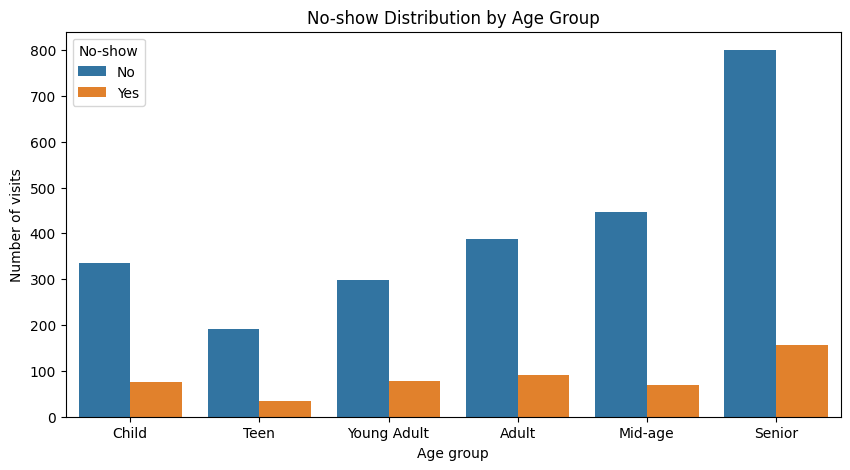

In [65]:
# ============================================================
# 7. Age groups and no-show behavior
# ============================================================

# Define age groups to simplify interpretation for non-technical stakeholders.
df["age_group"] = pd.cut(
    df["patient_age"],
    bins=[0, 12, 18, 30, 45, 60, 90],
    labels=["Child", "Teen", "Young Adult", "Adult", "Mid-age", "Senior"]
)

# 7.1 No-show distribution by age group
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="age_group", hue="no_show")
plt.title("No-show Distribution by Age Group")
plt.xlabel("Age group")
plt.ylabel("Number of visits")
plt.legend(title="No-show")
plt.show()

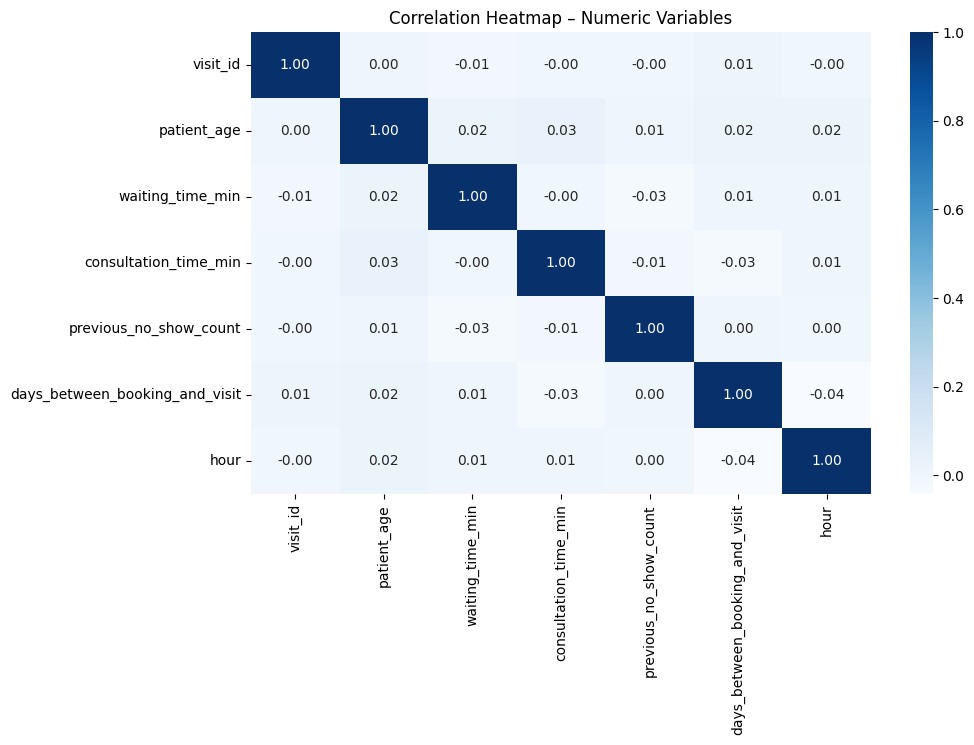

In [66]:
# ============================================================
# 8. Correlation analysis (numeric features)
# ============================================================

# Select only numeric columns for the correlation matrix.
numeric_corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap – Numeric Variables")
plt.show()

In [67]:
# ============================================================
# 9. Outlier detection using IQR method
# ============================================================

# The IQR method is a simple and robust way to identify extreme values.
numeric_cols = ["waiting_time_min", "consultation_time_min", "patient_age",
                "days_between_booking_and_visit"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} potential outliers (using IQR method)")

waiting_time_min: 12 potential outliers (using IQR method)
consultation_time_min: 18 potential outliers (using IQR method)
patient_age: 0 potential outliers (using IQR method)
days_between_booking_and_visit: 0 potential outliers (using IQR method)


In [68]:
# ============================================================
# 10. Feature engineering for predictive modeling
# ============================================================

# We will prepare a modeling dataset to predict no-shows.
# Steps:
#  - Encode categorical variables using one-hot encoding
#  - Create a binary target variable (0 = attended, 1 = no-show)

model_df = df.copy()

# One-hot encode selected categorical variables.
# drop_first=True avoids multicollinearity by excluding one category per variable.
model_df = pd.get_dummies(
    model_df,
    columns=["specialty", "gender", "urgency_level", "reason_for_visit"],
    drop_first=True
)

# Create binary target: 1 if no_show == "Yes", else 0.
model_df["no_show_flag"] = (model_df["no_show"] == "Yes").astype(int)

model_df.head()

,visit_id,consultation_date,consultation_time,patient_age,waiting_time_min,consultation_time_min,diagnosis_code,diagnosis_description,no_show,physician_id,previous_no_show_count,days_between_booking_and_visit,hour,age_group,specialty_Dermatology,specialty_Emergency Medicine,specialty_Endocrinology,specialty_General Medicine,specialty_General Surgery,specialty_Internal Medicine,specialty_Neurology,specialty_Ophthalmology,specialty_Orthopedics,specialty_Pediatrics,specialty_Psychiatry,specialty_Urology,gender_Male,urgency_level_Low,urgency_level_Medium,reason_for_visit_Emergency consultation,reason_for_visit_Follow-up visit,reason_for_visit_Imaging results review,reason_for_visit_Laboratory results review,reason_for_visit_Medication refill,reason_for_visit_New complaint,reason_for_visit_Post-surgery control,reason_for_visit_Pre-surgery evaluation,reason_for_visit_Routine check-up,no_show_flag
0,1,2024-11-23,08:00,35,29,27,K21.9,Gastro-esophageal reflux,No,DOC007,4,14,8,Adult,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,False,True,False,False,False,0
1,2,2024-09-15,16:00,25,28,25,J06.9,Acute upper respiratory infection,No,DOC025,3,21,16,Young Adult,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,0
2,3,2024-02-22,08:45,45,3,11,N39.0,Urinary tract infection,No,DOC018,0,18,8,Adult,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,0
3,4,2024-11-17,16:30,24,35,19,R07.4,Chest pain,No,DOC015,1,40,16,Young Adult,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,0
4,5,2024-07-05,09:30,26,18,9,I10,Essential (primary) hypertension,No,DOC015,1,24,9,Young Adult,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,0


In [69]:
# ============================================================
# 11. Train/test split and baseline logistic regression model
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define feature set X and target y.
# We exclude variables that are identifiers or not useful for modeling.
X = model_df.drop(
    [
        "no_show",
        "no_show_flag",
        "consultation_date",
        "consultation_time",
        "diagnosis_code",
        "diagnosis_description",
        "physician_id",
        "age_group",
        "hour"
    ],
    axis=1
)

y = model_df["no_show_flag"]

# Split into training and test sets to evaluate generalization performance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Initialize a simple Logistic Regression model (baseline).
log_reg = LogisticRegression(max_iter=200)

# Train the model on the training set.
log_reg.fit(X_train, y_train)

# Predict on the test set.
y_pred = log_reg.predict(X_test)

# Evaluate performance using accuracy and a detailed classification report.
print("Baseline Logistic Regression – Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Baseline Logistic Regression – Accuracy: 0.829

Classification Report:

              precision    recall  f1-score   support

           0       0.83      1.00      0.91       622
           1       0.00      0.00      0.00       128

    accuracy                           0.83       750
   macro avg       0.41      0.50      0.45       750
weighted avg       0.69      0.83      0.75       750



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

In [70]:
# ============================================================
# 12. Export cleaned dataset for BI tools (e.g., Power BI)
# ============================================================

# In this step, we export the current version of the dataset
# so that it can be used in a dashboard (Power BI, Tableau, etc.).
# In Colab, this file can be downloaded and placed into the /powerbi folder
# of the GitHub repository.

clean_filename = "clean_outpatients.csv"
df.to_csv(clean_filename, index=False)
print(f"Clean dataset exported as {clean_filename}")

Clean dataset exported as clean_outpatients.csv


In [71]:
# Optional: in Colab, download the exported CSV to your local machine.
from google.colab import files
files.download("clean_outpatients.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>